In [1]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("scikit-learn installed successfully!")

scikit-learn installed successfully!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 541909
Columns: 8


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(5268)

In [10]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [11]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(9288)

In [12]:
# Remove cancelled transactions
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print("Rows after removing cancellations:", len(df))

Rows after removing cancellations: 532621


In [13]:
# Remove transactions with missing CustomerID
df = df.dropna(subset=['CustomerID'])

print("Rows after removing missing CustomerID:", len(df))

Rows after removing missing CustomerID: 397924


In [14]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 392732


In [15]:
# Keep only valid purchases
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Rows after removing invalid purchases:", len(df))

Rows after removing invalid purchases: 392692


In [16]:
print("Final dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Final dataset shape: (392692, 8)

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [17]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [18]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [19]:
print("Final dataset shape:", df.shape)

Final dataset shape: (392692, 9)


In [20]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [21]:
# Set the reference date for calculating Recency
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference date:", reference_date)

Reference date: 2011-12-10 12:50:00


In [22]:
# Create RFM features for each customer

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

# Rename the columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [23]:
print("Number of customers:", rfm.shape[0])

Number of customers: 4338


In [24]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [25]:
print("Missing values in RFM:")
print(rfm.isnull().sum())

Missing values in RFM:
Recency      0
Frequency    0
Monetary     0
dtype: int64


In [26]:
rfm['AveragePurchaseValue'] = rfm['Monetary'] / rfm['Frequency']

rfm[['Frequency', 'Monetary', 'AveragePurchaseValue']].head()

,Frequency,Monetary,AveragePurchaseValue
CustomerID,,,
12346.0,1,77183.60,77183.600000
12347.0,7,4310.00,615.714286
12348.0,4,1797.24,449.310000
12349.0,1,1757.55,1757.550000
12350.0,1,334.40,334.400000


In [27]:
rfm['CustomerLifetimeValue'] = rfm['Monetary']

rfm.head()

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
CustomerID,,,,,
12346.0,326,1,77183.60,77183.600000,77183.60
12347.0,2,7,4310.00,615.714286,4310.00
12348.0,75,4,1797.24,449.310000,1797.24
12349.0,19,1,1757.55,1757.550000,1757.55
12350.0,310,1,334.40,334.400000,334.40


In [28]:
print("Number of customers:", rfm.shape[0])

Number of customers: 4338


In [29]:
rfm.describe()

,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081,417.645735,2048.688081
std,100.014169,7.697998,8985.230220,1796.511343,8985.230220
min,1.000000,1.000000,3.750000,3.450000,3.750000
25%,18.000000,1.000000,306.482500,177.867083,306.482500
50%,51.000000,2.000000,668.570000,291.940000,668.570000
75%,142.000000,5.000000,1660.597500,428.280625,1660.597500
max,374.000000,209.000000,280206.020000,84236.250000,280206.020000


In [30]:
# Select RFM features for clustering
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

rfm_features.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm_features.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


In [32]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

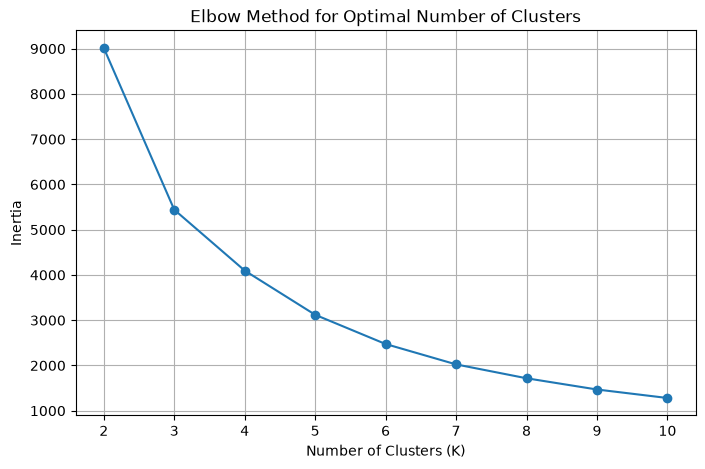

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.grid(True)

plt.savefig('images/elbow_method.png', bbox_inches='tight')
plt.show()

In [34]:
for k, value in zip(range(2, 11), inertia):
    print(f"K = {k}: Inertia = {value:.2f}")

K = 2: Inertia = 9014.57
K = 3: Inertia = 5441.32
K = 4: Inertia = 4096.30
K = 5: Inertia = 3119.79
K = 6: Inertia = 2473.79
K = 7: Inertia = 2023.59
K = 8: Inertia = 1717.01
K = 9: Inertia = 1468.79
K = 10: Inertia = 1281.05


In [35]:
from sklearn.cluster import KMeans

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed successfully!")
print("Number of clusters:", rfm['Cluster'].nunique())

K-Means clustering completed successfully!
Number of clusters: 4


In [36]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

print("Customers in each cluster:")
print(cluster_counts)

Customers in each cluster:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64


In [37]:
cluster_profile = rfm.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary',
     'AveragePurchaseValue', 'CustomerLifetimeValue']
].mean().round(2)

print("Customer Segment Profile:")
display(cluster_profile)

Customer Segment Profile:


,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
Cluster,,,,,
0,43.70,3.68,1353.63,375.06,1353.63
1,248.08,1.55,478.85,313.70,478.85
2,7.38,82.54,127187.96,8569.26,127187.96
3,15.50,22.33,12690.50,1079.42,12690.50


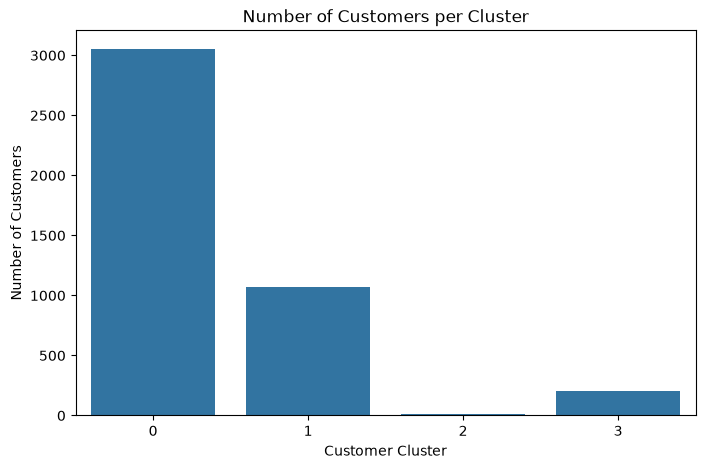

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    x='Cluster',
    data=rfm,
    order=sorted(rfm['Cluster'].unique())
)

plt.title('Number of Customers per Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.savefig('images/customers_per_cluster.png', bbox_inches='tight')
plt.show()

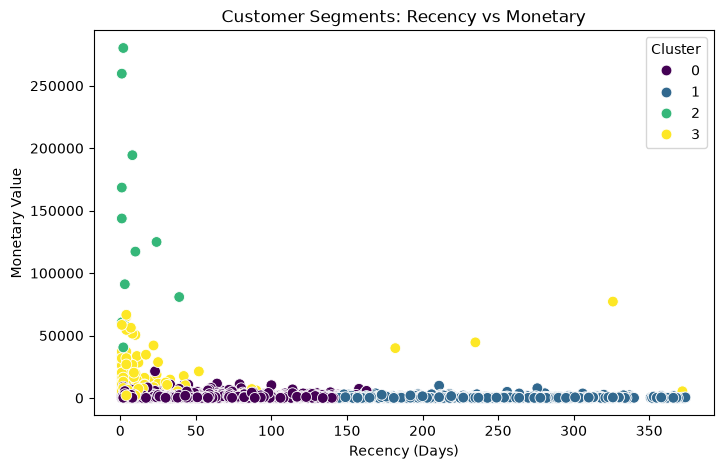

In [46]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')
plt.savefig('images/recency_vs_monetary.png', bbox_inches='tight')
plt.show()

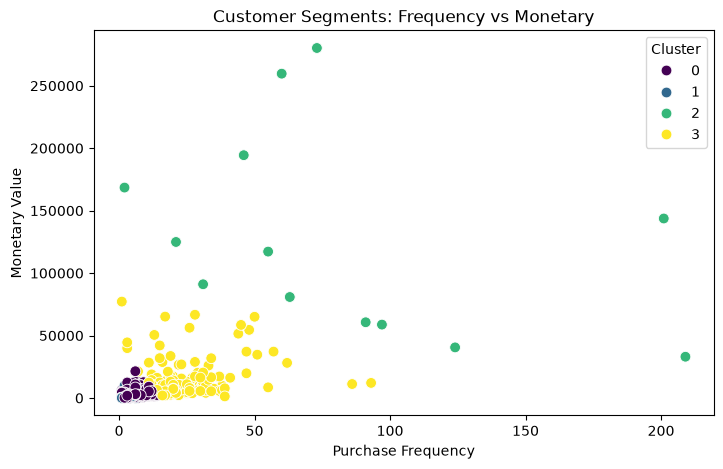

In [47]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=60
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')
plt.savefig('images/frequency_vs_monetary.png', bbox_inches='tight')
plt.show()

In [41]:
segment_names = {
    0: 'Regular Customers',
    1: 'At-Risk / Inactive Customers',
    2: 'Champions / VIP Customers',
    3: 'Loyal High-Value Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

print("Customer segments assigned successfully!")
display(
    rfm[['Cluster', 'Segment']]
    .drop_duplicates()
    .sort_values('Cluster')
)

Customer segments assigned successfully!


,Cluster,Segment
CustomerID,,
12347.0,0,Regular Customers
12350.0,1,At-Risk / Inactive Customers
12415.0,2,Champions / VIP Customers
12346.0,3,Loyal High-Value Customers


In [42]:
marketing_actions = pd.DataFrame({
    'Cluster': [0, 1, 2, 3],
    'Segment': [
        'Regular Customers',
        'At-Risk / Inactive Customers',
        'Champions / VIP Customers',
        'Loyal High-Value Customers'
    ],
    'Marketing Action': [
        'Use personalized recommendations, product bundles and loyalty rewards.',
        'Send win-back emails, special discounts and limited-time offers.',
        'Provide VIP rewards, exclusive products, early access and premium service.',
        'Encourage repeat purchases through loyalty programs, cross-selling and personalized offers.'
    ]
})

display(marketing_actions)

,Cluster,Segment,Marketing Action
0,0,Regular Customers,"Use personalized recommendations, product bund..."
1,1,At-Risk / Inactive Customers,"Send win-back emails, special discounts and li..."
2,2,Champions / VIP Customers,"Provide VIP rewards, exclusive products, early..."
3,3,Loyal High-Value Customers,Encourage repeat purchases through loyalty pro...


## Conclusion

Customer segmentation was performed using RFM (Recency, Frequency, and Monetary) analysis and K-Means clustering. The Elbow Method was used to select 4 clusters, and the RFM features were standardized using StandardScaler before clustering.

The analysis identified four distinct customer segments: Regular Customers, At-Risk / Inactive Customers, Champions / VIP Customers, and Loyal High-Value Customers. The Champions / VIP segment represents customers with very recent purchases, high purchase frequency, and exceptionally high monetary value, while the At-Risk / Inactive segment contains customers with low purchase frequency and older purchase activity.

These segments can help an e-commerce business develop targeted marketing strategies. VIP customers can be rewarded with exclusive benefits, loyal customers can be encouraged through personalized offers, regular customers can be nurtured with recommendations and loyalty rewards, and at-risk customers can be targeted with win-back campaigns and special discounts.

Overall, customer segmentation helps the business understand customer purchasing behaviour and make more effective, data-driven marketing decisions.
